In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Check if you are using a GPU (Nvidia) or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cpu


In [2]:
# Standard ImageNet normalization values (required for pre-trained models)
mean_nums = [0.485, 0.456, 0.406]
std_nums  = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((64, 64)),      # ResNet expects 64x64
        transforms.RandomHorizontalFlip(),  # Augmentation: Flip images to learn better
        transforms.ToTensor(),              # Convert to Tensor (numbers 0-1)
        transforms.Normalize(mean_nums, std_nums)
    ]),
    'val': transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean_nums, std_nums)
    ]),
}

In [3]:
data_dir = 'data' # This must match your folder name inside 'backend'

# 1. Load the Datasets from folders
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# 2. Create the DataLoaders (The "Conveyor Belt")
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x],
                                              batch_size=32,
                                              shuffle=True,
                                              num_workers=0) # Set to 0 for Windows compatibility
              for x in ['train', 'val']}

# 3. Get sizes and class names
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"✅ Found {dataset_sizes['train']} training images and {dataset_sizes['val']} validation images.")
print(f"✅ Classes ({len(class_names)}): {class_names}")

✅ Found 14847 training images and 3706 validation images.
✅ Classes (16): ['Bacterial leaf blight', 'Brown spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Leaf smut', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy']


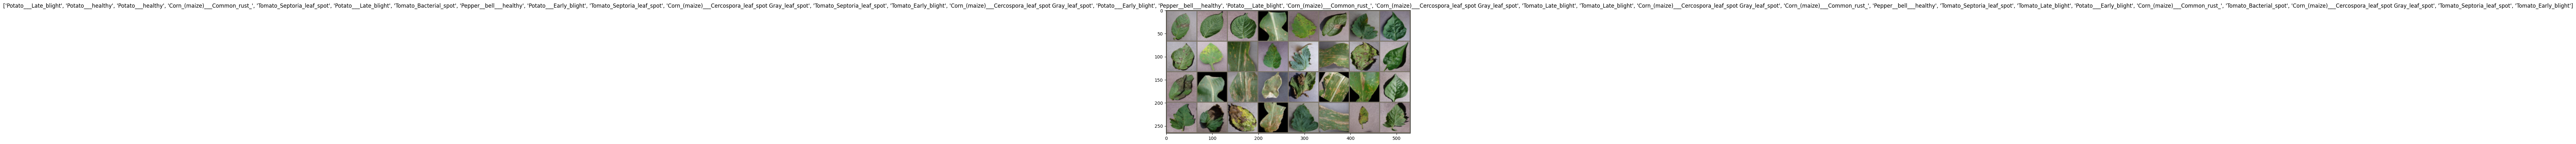

In [4]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Convert from Tensor (C, H, W) back to numpy (H, W, C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean # Undo the normalization math
    inp = np.clip(inp, 0, 1) # Ensure values are between 0 and 1
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

plt.figure(figsize=(15, 5))
imshow(out, title=[class_names[x] for x in classes])

## Building the Convolutional Neural Network Model

In [9]:
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Layer 1: Input 64x64 -> Output 32x32
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Layer 2: Input 32x32 -> Output 16x16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Layer 3: Input 16x16 -> Output 8x8
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Flattening Math:
        # We have 64 filters. The image size is now 8x8.
        # 64 * 8 * 8 = 4,096 inputs.
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Pass through the layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # --- THE FIX IS HERE ---
        # We must flatten using the exact output size (64 * 8 * 8)
        x = x.view(-1, 64 * 8 * 8)

        # Classification
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 1. Instantiate the Fixed Model
model = SimpleCNN(num_classes=len(class_names))
model = model.to(device)

# 2. Re-Define the Optimizer (CRITICAL step!)
# Since we deleted the old model, the old optimizer is holding onto "dead" connections.
# We must give it the new model's parameters.
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

print("✅ Model fixed and Optimizer reset!")

✅ Model fixed and Optimizer reset!


### The Engine

In [10]:
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_acc_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode (allows learning)
            else:
                model.eval()   # Set model to evaluate mode (locks the brain)

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data (The Conveyor Belt)
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                # (Clear the memory of the last batch so we don't get confused)
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)              # 1. Guess
                    _, preds = torch.max(outputs, 1)     # 2. Pick winner
                    loss = criterion(outputs, labels)    # 3. Calculate Error

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()  # 4. Calculate corrections (Gradients)
                        optimizer.step() # 5. Update weights

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model if it's the best one so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            # Save history for plotting later
            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
            else:
                val_acc_history.append(epoch_acc.item())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'🏆 Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history

In [11]:
import torch.optim as optim

# This calculates the error (Loss)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

print("✅ Rules defined: CrossEntropyLoss + SGD Optimizer")

✅ Rules defined: CrossEntropyLoss + SGD Optimizer


In [ ]:
# Train the model for 10 epochs (rounds)
# This might take 15-30 minutes on your CPU, so be patient!
model_ft, train_hist, val_hist = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 1/10
----------
train Loss: 1.8733 Acc: 0.4020
